# 7.1. EEG Decoding: Classification Basics

**Learning Objectives:**
- Understand the fundamentals of decoding/MVPA (Multi-Voxel Pattern Analysis)
- Learn to prepare EEG/MEG data for machine learning
- Apply scikit-learn classifiers to brain data
- Implement proper cross-validation strategies
- Evaluate classifier performance with multiple metrics
- Understand temporal generalization and time-resolved decoding
- Visualize decoding results and interpret classifier weights

**Key Concepts:**
- **Decoding**: Predicting experimental conditions from brain activity patterns
- **MVPA**: Multi-variate pattern analysis - using patterns across sensors/features
- **Cross-Validation**: Splitting data to avoid overfitting and estimate generalization
- **Feature Engineering**: Extracting informative features from raw signals
- **Temporal Generalization**: Testing if patterns learned at one time generalize to others
- **Permutation Testing**: Statistical validation of decoding accuracy

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import mne
from mne.datasets import sample
from mne.decoding import (
    Vectorizer, Scaler, cross_val_multiscore,
    SlidingEstimator, GeneralizingEstimator
)

import pandas as pd
from scipy import stats

# Scikit-learn imports
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score, permutation_test_score
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
sns.set_context("notebook", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
mne.set_config('MNE_TQDM', 'off')

## 1. Understanding Decoding Analysis

### What is Decoding?

**Decoding** (also called **MVPA** - Multi-Variate Pattern Analysis) uses machine learning to predict experimental conditions from patterns of brain activity.

**Traditional Analysis:**
- "Which brain regions respond to condition A?"
- Univariate: One sensor/voxel at a time
- Mass univariate testing

**Decoding Analysis:**
- "Can we predict which condition the participant saw from brain patterns?"
- Multivariate: Patterns across many sensors/voxels
- More sensitive to distributed representations

### Why Decode Brain Signals?

**Advantages:**
1. **Increased Sensitivity**: Can detect subtle distributed patterns
2. **Information Content**: Quantifies how much information is present
3. **Temporal Dynamics**: Track when information is available
4. **Generalization**: Test if representations generalize across contexts
5. **Brain-Computer Interfaces**: Direct applications to BCI

**Applications:**
- Predict stimulus category (faces vs houses)
- Decode motor intention (left vs right hand)
- Classify cognitive states (attention vs distraction)
- Track information flow through time

### Common Classifiers for EEG/MEG

| Classifier | Pros | Cons | Best For |
|------------|------|------|----------|
| **Logistic Regression** | Fast, interpretable, regularization | Linear only | General purpose, high-dim data |
| **Linear Discriminant Analysis (LDA)** | Optimal for Gaussian data, fast | Assumes equal covariance | Small sample sizes |
| **Support Vector Machine (SVM)** | Powerful, kernel methods | Slower, less interpretable | Complex boundaries |
| **Naive Bayes** | Very fast, works with little data | Strong independence assumption | Quick baselines |
| **Random Forest** | Non-linear, robust | Less interpretable, can overfit | Feature importance |

For EEG/MEG, **regularized logistic regression** and **LDA** are most common due to high dimensionality.

## 2. Load Sample Data & Preprocessing

In [3]:
# Set up paths
repo_root = Path("./").resolve().parents[1]
target_dir = repo_root / "datasets" / "meg_sample"
target_dir.mkdir(parents=True, exist_ok=True)

data_path = sample.data_path(path=str(target_dir), download=True)
subjects_dir = data_path / 'subjects'

# Load MEG data
meg_file = data_path / "MEG" / "sample" / "sample_audvis_raw.fif"
events_fname = data_path / 'MEG' / 'sample' / 'sample_audvis_raw-eve.fif'

raw = mne.io.read_raw_fif(meg_file, preload=True)
events = mne.read_events(events_fname)

print(f"Loaded raw data with {len(raw.ch_names)} channels")
print(f"Found {len(events)} events")

Opening raw data file /Users/yibeisita/Documents/neuro-ai-playground/datasets/meg_sample/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
Loaded raw data with 376 channels
Found 320 events


In [4]:
# Basic preprocessing
raw.filter(l_freq=1.0, h_freq=40.0, n_jobs=1)
raw.pick_types(meg='grad', eeg=False, eog=False, stim=False)

print(f"Filtered data, {len(raw.ch_names)} gradiometer channels")

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1983 samples (3.302 s)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtered data, 203 gradiometer channels


In [5]:
# Create epochs for decoding
# We'll decode auditory vs visual stimuli

event_id_separate = {
    'auditory/left': 1, 
    'auditory/right': 2, 
    'visual/left': 3, 
    'visual/right': 4
}

tmin, tmax = -0.2, 0.5

epochs = mne.Epochs(
    raw, events, event_id_separate, tmin, tmax,
    baseline=(None, 0), preload=True,
    reject=dict(grad=4000e-13),
    decim=4  # Downsample for faster computation
)

# Now combine the conditions by modifying the event IDs
# Map all auditory (1,2) to 0 and all visual (3,4) to 1
epochs.events[:, 2] = (epochs.events[:, 2] >= 3).astype(int)
epochs.event_id = {'auditory': 0, 'visual': 1}

print(f"Created {len(epochs)} epochs")
print(f"Epochs shape: {epochs.get_data().shape}")
print(f"\nClass distribution:")
print(f"  auditory: {len(epochs['auditory'])} trials")
print(f"  visual: {len(epochs['visual'])} trials")

Not setting metadata
289 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 289 events and 421 original time points (prior to decimation) ...
0 bad epochs dropped
Created 289 epochs
Epochs shape: (289, 203, 106)

Class distribution:
  auditory: 145 trials
  visual: 144 trials


## 3. Basic Time-Averaged Decoding

### 3.1. Prepare Data for Classification

**Feature Matrix Construction:**

For time-averaged decoding, we average each epoch over a time window of interest:
- **X**: Feature matrix, shape `(n_trials, n_features)`
  - Each row is one trial
  - Each column is one sensor (averaged over time)
- **y**: Labels, shape `(n_trials,)`
  - The condition for each trial (e.g., 0=auditory, 1=visual)

**Time Window Selection:**
- **Baseline**: -200 to 0 ms (should not be decodable)
- **Early Response**: 50-150 ms (sensory processing)
- **Late Response**: 200-400 ms (higher-level processing)

In [6]:
# Define time windows for averaging
time_windows = {
    'baseline': (-0.2, 0),
    'early': (0.05, 0.15),
    'late': (0.2, 0.4)
}

# Function to create feature matrix for a time window
def create_features(epochs, tmin, tmax):
    """
    Create feature matrix by averaging epochs over a time window.
    """
    # Crop to time window and average
    epochs_crop = epochs.copy().crop(tmin, tmax)
    X = epochs_crop.get_data().mean(axis=2)  # Average over time
    
    # Get labels directly (already 0 for auditory and 1 for visual)
    y = epochs.events[:, 2]
    
    return X, y

# Create features for early window
X_early, y = create_features(epochs, *time_windows['early'])

print(f"Feature matrix shape: {X_early.shape}")
print(f"  {X_early.shape[0]} trials")
print(f"  {X_early.shape[1]} features (channels)")
print(f"\nLabels shape: {y.shape}")
print(f"  Auditory (0): {np.sum(y == 0)} trials")
print(f"  Visual (1): {np.sum(y == 1)} trials")

Feature matrix shape: (289, 203)
  289 trials
  203 features (channels)

Labels shape: (289,)
  Auditory (0): 145 trials
  Visual (1): 144 trials


### 3.2. Train a Simple Classifier

**Pipeline Construction:**

We use scikit-learn pipelines to chain preprocessing and classification:
1. **StandardScaler**: Normalize features (zero mean, unit variance)
2. **LogisticRegression**: Linear classifier with L2 regularization

In [7]:
# Create a simple pipeline
clf = make_pipeline(
    StandardScaler(),  # Normalize features
    LogisticRegression(
        solver='liblinear',  # Fast for small datasets
        random_state=42
    )
)

print("Pipeline created:")
print(clf)

Pipeline created:
Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(random_state=42, solver='liblinear'))])


### 3.3. Cross-Validation

**Why Cross-Validation?**

- **Avoid overfitting**: Model might memorize training data
- **Estimate generalization**: How well does it work on new data?
- **Use all data efficiently**: Every trial used for both training and testing

**Stratified K-Fold:**
- Split data into K folds (typically 5)
- Train on K-1 folds, test on remaining fold
- Repeat K times, each fold used once as test set
- **Stratified**: Maintains class proportions in each fold

In [8]:
# Set up cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
scores_early = cross_val_score(clf, X_early, y, cv=cv, scoring='accuracy')

print(f"Cross-validation results (early window: {time_windows['early'][0]*1000:.0f}-{time_windows['early'][1]*1000:.0f} ms):")
print(f"  Accuracy per fold: {scores_early}")
print(f"  Mean accuracy: {scores_early.mean():.3f}")
print(f"  Std: ± {scores_early.std():.3f}")
print(f"\nChance level: 0.500 (50% for binary classification)")
print(f"Above chance: {scores_early.mean() > 0.5}")

Cross-validation results (early window: 50-150 ms):
  Accuracy per fold: [0.9137931  0.87931034 0.98275862 0.93103448 0.8245614 ]
  Mean accuracy: 0.906
  Std: ± 0.053

Chance level: 0.500 (50% for binary classification)
Above chance: True


### 3.4. Compare Time Windows

In [9]:
# Decode for all time windows
results = {}

for window_name, (tmin, tmax) in time_windows.items():
    # Create features
    X, y = create_features(epochs, tmin, tmax)
    
    # Cross-validate
    scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')
    
    results[window_name] = {
        'scores': scores,
        'mean': scores.mean(),
        'std': scores.std(),
        'window': (tmin, tmax)
    }
    
    print(f"{window_name:10s} ({tmin*1000:4.0f}-{tmax*1000:4.0f} ms): {scores.mean():.3f} ± {scores.std():.3f}")

baseline   (-200-   0 ms): 0.550 ± 0.029
early      (  50- 150 ms): 0.906 ± 0.053
late       ( 200- 400 ms): 0.824 ± 0.050


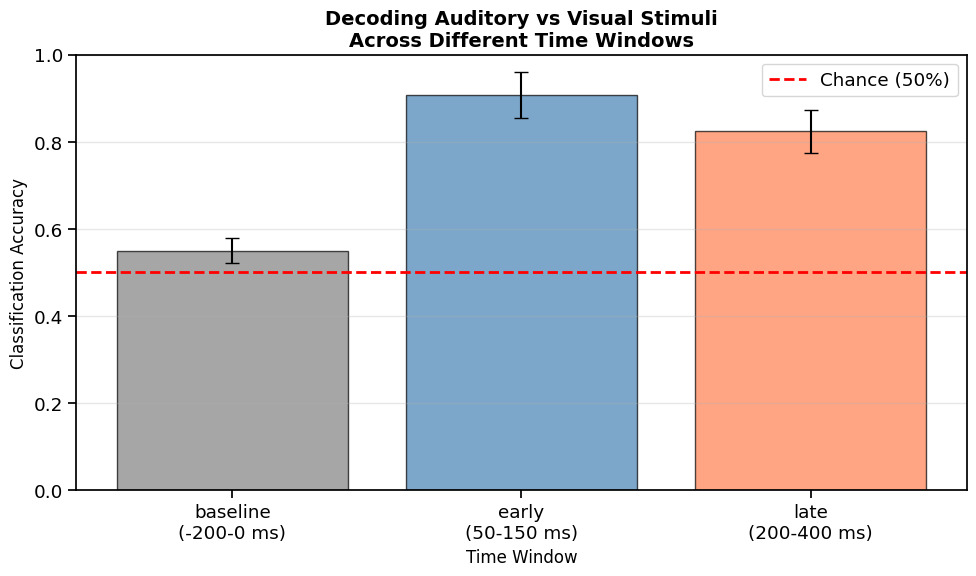


Statistical significance (t-test vs chance=0.5):
  baseline  : t= 3.46, p=0.0259 *
  early     : t=15.40, p=0.0001 ***
  late      : t=12.97, p=0.0002 ***


In [10]:
# Visualize results
fig, ax = plt.subplots(figsize=(10, 6))

window_names = list(results.keys())
means = [results[w]['mean'] for w in window_names]
stds = [results[w]['std'] for w in window_names]

x_pos = np.arange(len(window_names))
bars = ax.bar(x_pos, means, yerr=stds, capsize=5, color=['gray', 'steelblue', 'coral'], alpha=0.7, edgecolor='black')

# Add chance level line
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Chance (50%)')

ax.set_xlabel('Time Window', fontsize=12)
ax.set_ylabel('Classification Accuracy', fontsize=12)
ax.set_title('Decoding Auditory vs Visual Stimuli\nAcross Different Time Windows', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f"{w}\n({results[w]['window'][0]*1000:.0f}-{results[w]['window'][1]*1000:.0f} ms)" 
                     for w in window_names])
ax.set_ylim([0, 1])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Statistical test: is it above chance?
print("\nStatistical significance (t-test vs chance=0.5):")
for window_name in window_names:
    scores = results[window_name]['scores']
    t_stat, p_val = stats.ttest_1samp(scores, 0.5)
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "n.s."
    print(f"  {window_name:10s}: t={t_stat:5.2f}, p={p_val:.4f} {sig}")

## 4. Time-Resolved Decoding

### Tracking Information Over Time

Instead of averaging over a fixed window, we can train a classifier at each time point to see **when** information becomes available.

**Approach:**
1. For each time point t:
   - Use activity at time t across all sensors as features
   - Train classifier to predict condition
   - Evaluate with cross-validation
2. Plot accuracy over time

**MNE's SlidingEstimator:**
- Automatically handles time dimension
- Efficient implementation
- Compatible with scikit-learn pipelines

In [11]:
# Prepare data for time-resolved decoding
X = epochs.get_data()  # Shape: (n_epochs, n_channels, n_times)
y = epochs.events[:, 2]

print(f"Data shape for time-resolved decoding: {X.shape}")
print(f"  {X.shape[0]} trials")
print(f"  {X.shape[1]} channels (features per time point)")
print(f"  {X.shape[2]} time points")

Data shape for time-resolved decoding: (289, 203, 106)
  289 trials
  203 channels (features per time point)
  106 time points


In [12]:
# Create sliding estimator
# This trains a classifier at each time point
clf_time = make_pipeline(
    StandardScaler(),
    LogisticRegression(solver='liblinear', random_state=42)
)

time_decoder = SlidingEstimator(clf_time, n_jobs=-1, scoring='accuracy', verbose=True)

# Perform time-resolved cross-validation
print("Running time-resolved decoding (this may take a minute)...")
scores_time = cross_val_multiscore(time_decoder, X, y, cv=cv)

# Average across folds
mean_scores = scores_time.mean(axis=0)
std_scores = scores_time.std(axis=0)

print(f"\nTime-resolved scores shape: {scores_time.shape}")
print(f"  {scores_time.shape[0]} CV folds")
print(f"  {scores_time.shape[1]} time points")
print(f"\nPeak accuracy: {mean_scores.max():.3f} at {epochs.times[mean_scores.argmax()]*1000:.0f} ms")

Running time-resolved decoding (this may take a minute)...

Time-resolved scores shape: (5, 106)
  5 CV folds
  106 time points

Peak accuracy: 0.979 at 93 ms


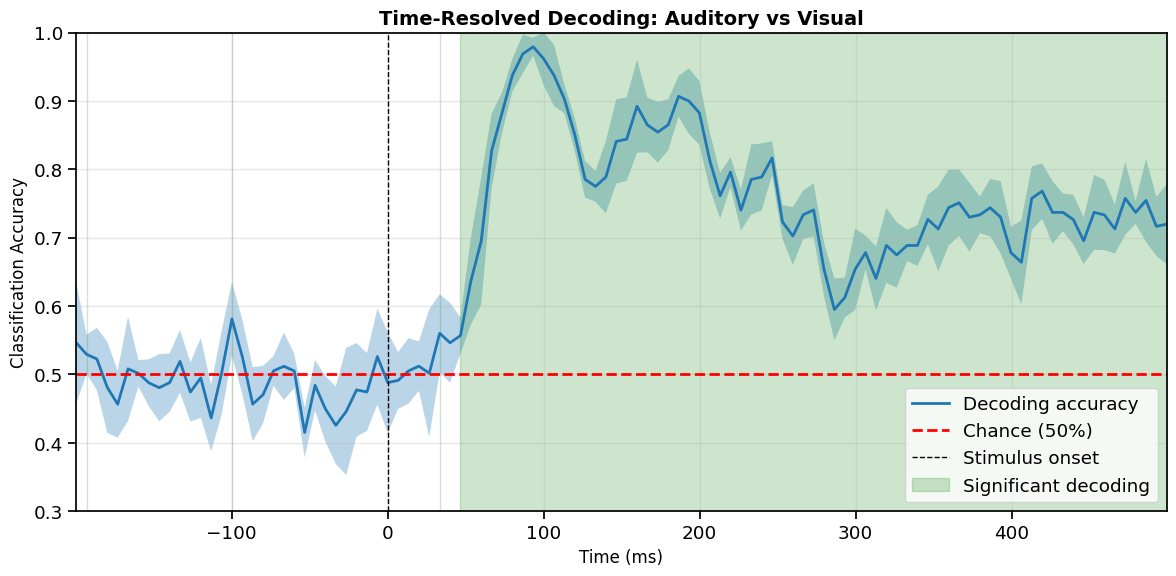


Significant decoding:
  First significant: -193 ms
  Last significant: 499 ms
  Duration: 693 ms


In [13]:
# Visualize time-resolved decoding
fig, ax = plt.subplots(figsize=(12, 6))

# Plot mean accuracy with confidence interval
times = epochs.times * 1000  # Convert to ms
ax.plot(times, mean_scores, linewidth=2, label='Decoding accuracy')
ax.fill_between(times, 
                 mean_scores - std_scores, 
                 mean_scores + std_scores,
                 alpha=0.3)

# Add chance level and stimulus onset
ax.axhline(0.5, color='red', linestyle='--', linewidth=2, label='Chance (50%)')
ax.axvline(0, color='black', linestyle='--', linewidth=1, label='Stimulus onset')

# Shade significant time points (above chance + 1 std)
sig_mask = mean_scores > (0.5 + std_scores)
if sig_mask.any():
    ax.fill_between(times, 0, 1, where=sig_mask, alpha=0.2, color='green', 
                     label='Significant decoding')

ax.set_xlabel('Time (ms)', fontsize=12)
ax.set_ylabel('Classification Accuracy', fontsize=12)
ax.set_title('Time-Resolved Decoding: Auditory vs Visual', fontsize=14, fontweight='bold')
ax.set_xlim([times[0], times[-1]])
ax.set_ylim([0.3, 1.0])
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find time points with significant decoding
sig_times = times[sig_mask]
if len(sig_times) > 0:
    print(f"\nSignificant decoding:")
    print(f"  First significant: {sig_times[0]:.0f} ms")
    print(f"  Last significant: {sig_times[-1]:.0f} ms")
    print(f"  Duration: {sig_times[-1] - sig_times[0]:.0f} ms")

## 5. Temporal Generalization

### Testing Pattern Stability

**Temporal Generalization Matrix:**
- Train classifier at time t₁
- Test at all times t₂
- Creates a 2D matrix: training time × testing time

**Interpretation:**
- **Diagonal**: Standard time-resolved decoding
- **Off-diagonal**: Generalization across time
- **Sustained activation**: Broad generalization (square pattern)
- **Transient activation**: Narrow generalization (diagonal only)

**What it tells us:**
- Do neural patterns remain stable or change over time?
- Are early and late processing stages using the same code?

In [14]:
# Create generalizing estimator
# This trains at each time and tests at all times
gen_decoder = GeneralizingEstimator(
    clf_time, 
    scoring='accuracy', 
    n_jobs=-1
)

print("Running temporal generalization (this will take a few minutes)...")
print("Training and testing at all time point pairs...")

# This creates a (n_times_train, n_times_test) matrix
scores_gen = cross_val_multiscore(gen_decoder, X, y, cv=cv)

# Average across CV folds
mean_scores_gen = scores_gen.mean(axis=0)

print(f"\nTemporal generalization matrix shape: {mean_scores_gen.shape}")
print(f"  {mean_scores_gen.shape[0]} training time points")
print(f"  {mean_scores_gen.shape[1]} testing time points")

Running temporal generalization (this will take a few minutes)...
Training and testing at all time point pairs...

Temporal generalization matrix shape: (106, 106)
  106 training time points
  106 testing time points


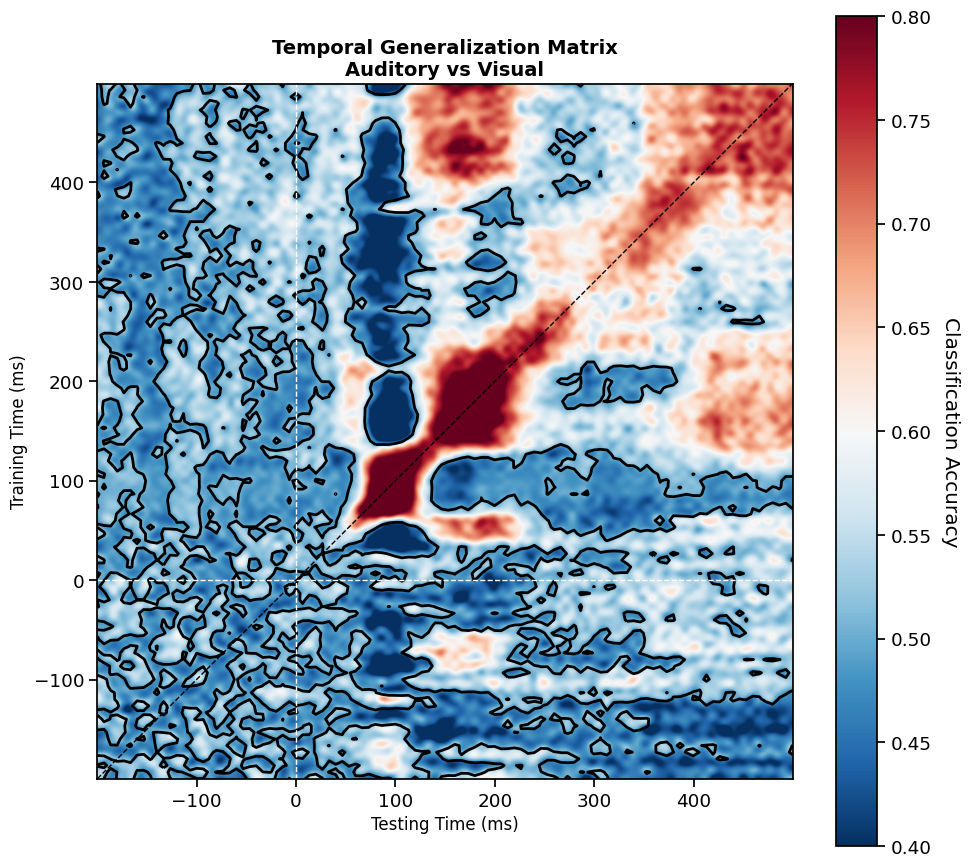


Interpretation:
  - Diagonal: Time-resolved decoding accuracy
  - Off-diagonal: Cross-temporal generalization
  - Broad patterns: Sustained neural representations
  - Narrow diagonal: Transient/changing representations


In [15]:
# Visualize temporal generalization matrix
fig, ax = plt.subplots(figsize=(10, 9))

im = ax.imshow(
    mean_scores_gen, 
    interpolation='lanczos',
    origin='lower',
    cmap='RdBu_r',
    extent=[times[0], times[-1], times[0], times[-1]],
    vmin=0.4, vmax=0.8
)

# Add chance level contour
ax.contour(
    mean_scores_gen, 
    levels=[0.5], 
    colors='black',
    extent=[times[0], times[-1], times[0], times[-1]],
    linewidths=2
)

# Add stimulus onset lines
ax.axvline(0, color='white', linestyle='--', linewidth=1)
ax.axhline(0, color='white', linestyle='--', linewidth=1)

# Add diagonal line
ax.plot([times[0], times[-1]], [times[0], times[-1]], 
        'k--', linewidth=1, label='Diagonal (train=test time)')

ax.set_xlabel('Testing Time (ms)', fontsize=12)
ax.set_ylabel('Training Time (ms)', fontsize=12)
ax.set_title('Temporal Generalization Matrix\nAuditory vs Visual', 
             fontsize=14, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Classification Accuracy', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  - Diagonal: Time-resolved decoding accuracy")
print("  - Off-diagonal: Cross-temporal generalization")
print("  - Broad patterns: Sustained neural representations")
print("  - Narrow diagonal: Transient/changing representations")

## 6. Comparing Classifiers

### Which Classifier is Best?

Different classifiers make different assumptions and may perform differently on EEG/MEG data.

In [16]:
# Define different classifiers
classifiers = {
    'Logistic Regression': make_pipeline(
        StandardScaler(),
        LogisticRegression(solver='liblinear', random_state=42)
    ),
    'LDA': make_pipeline(
        StandardScaler(),
        LinearDiscriminantAnalysis()
    ),
    'Linear SVM': make_pipeline(
        StandardScaler(),
        SVC(kernel='linear', random_state=42)
    ),
    'RBF SVM': make_pipeline(
        StandardScaler(),
        SVC(kernel='rbf', random_state=42)
    )
}

# Use early window for comparison
X_test, y_test = create_features(epochs, *time_windows['early'])

# Compare classifiers
clf_results = {}

print("Comparing classifiers on early window (50-150 ms):\n")

for clf_name, clf_model in classifiers.items():
    scores = cross_val_score(clf_model, X_test, y_test, cv=cv, scoring='accuracy')
    clf_results[clf_name] = {
        'scores': scores,
        'mean': scores.mean(),
        'std': scores.std()
    }
    print(f"{clf_name:20s}: {scores.mean():.3f} ± {scores.std():.3f}")

Comparing classifiers on early window (50-150 ms):

Logistic Regression : 0.906 ± 0.053
LDA                 : 0.723 ± 0.040
Linear SVM          : 0.896 ± 0.064
RBF SVM             : 0.903 ± 0.041


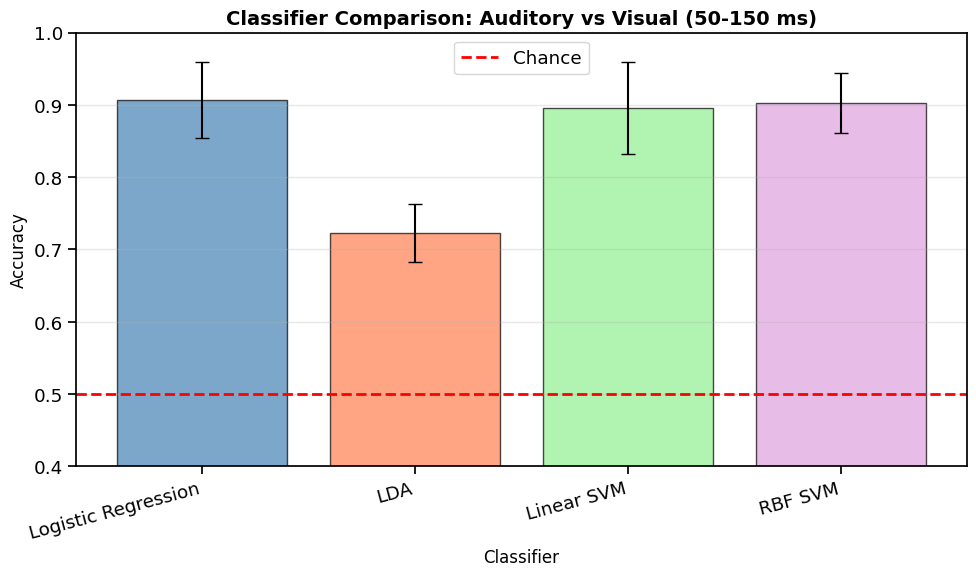

In [17]:
# Visualize classifier comparison
fig, ax = plt.subplots(figsize=(10, 6))

clf_names = list(clf_results.keys())
means = [clf_results[name]['mean'] for name in clf_names]
stds = [clf_results[name]['std'] for name in clf_names]

x_pos = np.arange(len(clf_names))
bars = ax.bar(x_pos, means, yerr=stds, capsize=5,
              color=['steelblue', 'coral', 'lightgreen', 'plum'],
              alpha=0.7, edgecolor='black')

ax.axhline(0.5, color='red', linestyle='--', linewidth=2, label='Chance')

ax.set_xlabel('Classifier', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Classifier Comparison: Auditory vs Visual (50-150 ms)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(clf_names, rotation=15, ha='right')
ax.set_ylim([0.4, 1.0])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. Detailed Performance Metrics

### Beyond Accuracy

Accuracy is useful but doesn't tell the whole story. We should also examine:
- **Confusion Matrix**: Which errors are made?
- **Precision & Recall**: Performance per class
- **ROC Curve**: Trade-off between true and false positives
- **AUC**: Area under ROC curve (discrimination ability)

In [18]:
# Train final model and get predictions for detailed analysis
from sklearn.model_selection import cross_val_predict

# Get cross-validated predictions
best_clf = classifiers['Logistic Regression']
y_pred = cross_val_predict(best_clf, X_test, y_test, cv=cv)

# Get prediction probabilities for ROC curve
# Note: Need to refit to get probabilities
clf_for_proba = make_pipeline(
    StandardScaler(),
    LogisticRegression(solver='liblinear', random_state=42)
)

# Use predict_proba method
y_proba = np.zeros((len(y_test), 2))
for train_idx, test_idx in cv.split(X_test, y_test):
    clf_for_proba.fit(X_test[train_idx], y_test[train_idx])
    y_proba[test_idx] = clf_for_proba.predict_proba(X_test[test_idx])

print("Generated predictions for detailed analysis")

Generated predictions for detailed analysis


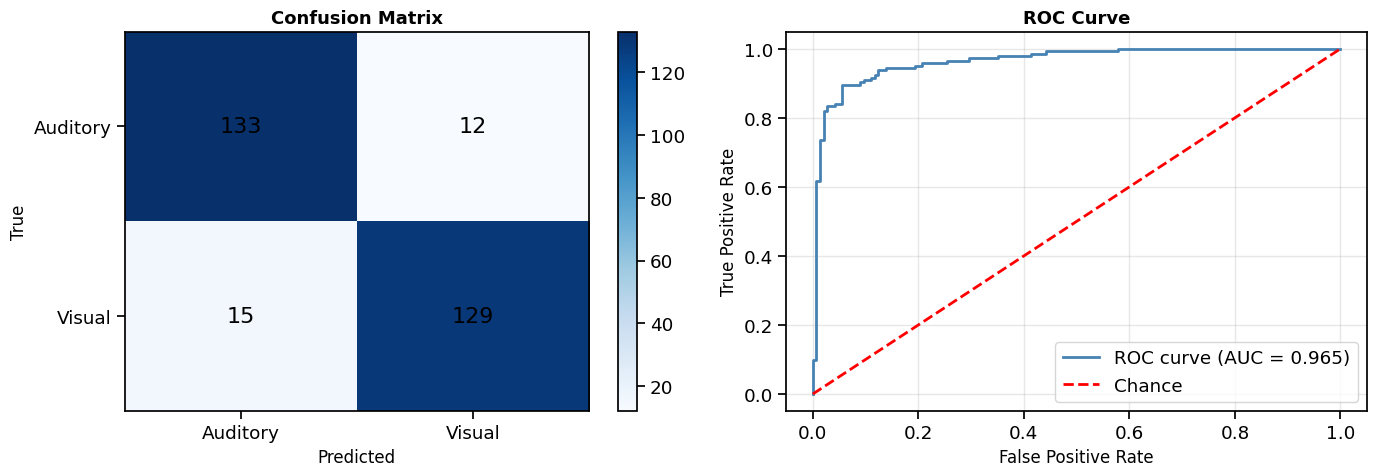


Classification Report:
              precision    recall  f1-score   support

    Auditory      0.899     0.917     0.908       145
      Visual      0.915     0.896     0.905       144

    accuracy                          0.907       289
   macro avg      0.907     0.907     0.907       289
weighted avg      0.907     0.907     0.907       289



In [19]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot confusion matrix
ax = axes[0]
im = ax.imshow(cm, cmap='Blues', aspect='auto')

# Add text annotations
for i in range(2):
    for j in range(2):
        text = ax.text(j, i, str(cm[i, j]),
                      ha="center", va="center", color="black", fontsize=16)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Auditory', 'Visual'])
ax.set_yticklabels(['Auditory', 'Visual'])
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax)

# ROC curve
ax = axes[1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba[:, 1])
roc_auc = roc_auc_score(y_test, y_proba[:, 1])

ax.plot(fpr, tpr, color='steelblue', linewidth=2, 
        label=f'ROC curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Chance')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, 
                           target_names=['Auditory', 'Visual'],
                           digits=3))

## 8. Statistical Validation: Permutation Testing

### Is Our Result Statistically Significant?

**Problem**: Cross-validation gives us an accuracy estimate, but how do we know it's not just luck?

**Solution**: Permutation testing
1. Shuffle labels randomly (destroy true relationship)
2. Re-run classification with shuffled labels
3. Repeat many times to build null distribution
4. Compare true accuracy to null distribution

**P-value**: Fraction of permutations that achieve accuracy ≥ true accuracy

In [20]:
# Permutation test (this takes a while)
print("Running permutation test (100 permutations)...")
print("This may take a few minutes...\n")

score, perm_scores, pvalue = permutation_test_score(
    best_clf, X_test, y_test,
    scoring='accuracy',
    cv=cv,
    n_permutations=100,
    n_jobs=1,
    random_state=42
)

print(f"True accuracy: {score:.3f}")
print(f"Permutation accuracy (mean): {perm_scores.mean():.3f}")
print(f"Permutation accuracy (std): {perm_scores.std():.3f}")
print(f"P-value: {pvalue:.4f}")
print(f"\nSignificant at p < 0.05: {pvalue < 0.05}")

Running permutation test (100 permutations)...
This may take a few minutes...

True accuracy: 0.906
Permutation accuracy (mean): 0.500
Permutation accuracy (std): 0.036
P-value: 0.0099

Significant at p < 0.05: True


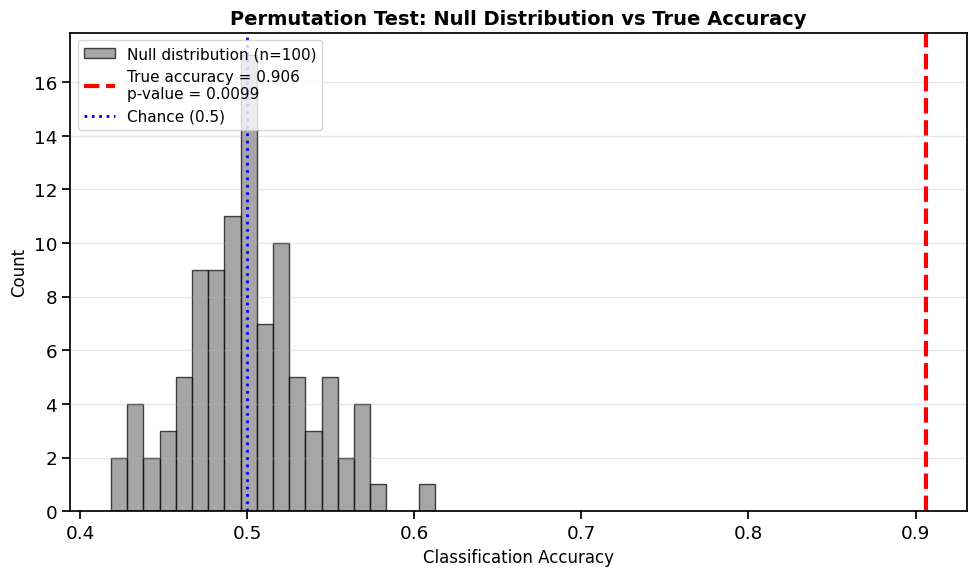

In [21]:
# Visualize permutation test results
fig, ax = plt.subplots(figsize=(10, 6))

# Histogram of permutation scores
ax.hist(perm_scores, bins=20, color='gray', alpha=0.7, edgecolor='black',
        label=f'Null distribution (n={len(perm_scores)})')

# Add true score
ax.axvline(score, color='red', linewidth=3, linestyle='--',
          label=f'True accuracy = {score:.3f}\np-value = {pvalue:.4f}')

# Add chance level
ax.axvline(0.5, color='blue', linewidth=2, linestyle=':',
          label='Chance (0.5)')

ax.set_xlabel('Classification Accuracy', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Permutation Test: Null Distribution vs True Accuracy',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 9. Interpreting the Classifier: Feature Importance

### Which Sensors Drive Classification?

For linear classifiers, the **weights** tell us which features (sensors) are most important.

**Interpretation:**
- **Positive weights**: Sensor activity predicts class 1 (visual)
- **Negative weights**: Sensor activity predicts class 0 (auditory)
- **Large magnitude**: Important for classification

We can visualize these weights as a **topographic map**.

In [22]:
# Train classifier on all data to get stable weights
clf_for_weights = make_pipeline(
    StandardScaler(),
    LogisticRegression(solver='liblinear', random_state=42)
)

clf_for_weights.fit(X_test, y_test)

# Extract weights from logistic regression
weights = clf_for_weights.named_steps['logisticregression'].coef_[0]

print(f"Classifier weights shape: {weights.shape}")
print(f"Number of features (channels): {len(weights)}")
print(f"\nWeight statistics:")
print(f"  Min: {weights.min():.3f}")
print(f"  Max: {weights.max():.3f}")
print(f"  Mean: {weights.mean():.3f}")
print(f"  Std: {weights.std():.3f}")

Classifier weights shape: (203,)
Number of features (channels): 203

Weight statistics:
  Min: -0.836
  Max: 0.874
  Mean: 0.007
  Std: 0.255


In [23]:
# Find most important sensors
n_top = 10
top_indices = np.argsort(np.abs(weights))[-n_top:][::-1]

print(f"\nTop {n_top} most important sensors:")
print(f"{'Rank':<6} {'Channel':<15} {'Weight':>10} {'Direction':<15}")
print("-" * 50)

for rank, idx in enumerate(top_indices, 1):
    ch_name = epochs.ch_names[idx]
    weight = weights[idx]
    direction = 'Visual' if weight > 0 else 'Auditory'
    print(f"{rank:<6} {ch_name:<15} {weight:>10.3f} {direction:<15}")


Top 10 most important sensors:
Rank   Channel             Weight Direction      
--------------------------------------------------
1      MEG 0243             0.874 Visual         
2      MEG 0242            -0.836 Auditory       
3      MEG 1922            -0.767 Auditory       
4      MEG 1332            -0.740 Auditory       
5      MEG 1333            -0.725 Auditory       
6      MEG 2412             0.723 Visual         
7      MEG 0213             0.616 Visual         
8      MEG 2042            -0.580 Auditory       
9      MEG 1123            -0.546 Auditory       
10     MEG 0143            -0.533 Auditory       


## Summary and Key Takeaways

### What We Learned

1. **Decoding Basics:**
   - Decoding uses machine learning to predict conditions from brain patterns
   - More sensitive than univariate analysis for distributed representations
   - Quantifies **information content** in brain signals

2. **Data Preparation:**
   - Feature matrix X: trials × features (sensors/timepoints)
   - Labels y: condition for each trial
   - Standardization/scaling is crucial for many classifiers
   - Time-averaging vs time-resolved approaches

3. **Cross-Validation:**
   - Essential to avoid overfitting and estimate generalization
   - Stratified K-Fold maintains class balance
   - Typically use 5-fold CV
   - Report mean ± std across folds

4. **Time-Resolved Decoding:**
   - Tracks **when** information becomes available
   - Use SlidingEstimator for efficiency
   - Plot accuracy over time to see information dynamics
   - Compare to stimulus onset and behavioral response

5. **Temporal Generalization:**
   - Tests if patterns learned at one time generalize to others
   - 2D matrix: train time × test time
   - Diagonal = standard decoding
   - Off-diagonal = cross-temporal generalization
   - Reveals sustained vs transient representations

6. **Classifier Selection:**
   - **Logistic Regression**: Good default, fast, interpretable
   - **LDA**: Optimal for Gaussian data, works well with small samples
   - **SVM**: Powerful but slower, good with kernel methods
   - Linear classifiers usually sufficient for EEG/MEG

7. **Performance Evaluation:**
   - **Accuracy**: Overall correctness (watch for class imbalance)
   - **Confusion Matrix**: See which errors are made
   - **Precision/Recall**: Per-class performance
   - **ROC/AUC**: Discrimination ability independent of threshold

8. **Statistical Validation:**
   - Permutation testing for significance
   - Build null distribution by shuffling labels
   - P-value from empirical null distribution
   - More robust than parametric tests

9. **Interpretation:**
   - Linear classifier weights show feature importance
   - Can visualize as topographic maps
   - Sign indicates which class is predicted
   - Magnitude indicates importance

### Best Practices

**Do's:**
- ✓ Always use cross-validation (never train and test on same data)
- ✓ Use stratified splits to maintain class balance
- ✓ Standardize features (especially for regularized methods)
- ✓ Report multiple metrics (accuracy, confusion matrix, etc.)
- ✓ Use permutation testing for statistical validation
- ✓ Visualize results (decoding curves, topographies)
- ✓ Check for class imbalance
- ✓ Try multiple classifiers

**Don'ts:**
- ✗ Don't train and test on the same data (data leakage)
- ✗ Don't use test data for any decisions (including feature selection)
- ✗ Don't forget to scale/normalize features
- ✗ Don't rely solely on accuracy (especially with imbalanced classes)
- ✗ Don't assume above-chance = meaningful (use permutation tests)
- ✗ Don't cherry-pick best time points post-hoc

### Common Pitfalls

1. **Data Leakage**: Using test data in any way during training
   - Solution: Strict train/test separation in CV

2. **Circular Analysis**: Selecting features based on test performance
   - Solution: Feature selection inside CV loop only

3. **Multiple Comparisons**: Testing many time points inflates false positives
   - Solution: Cluster-based permutation or FDR correction

4. **Class Imbalance**: Unequal numbers of trials per condition
   - Solution: Balanced sampling, weighted loss, or different metrics

5. **Overfitting**: Perfect training accuracy, poor generalization
   - Solution: Regularization, more data, simpler models